# Week 10 Lab
The dataset for this lab comes from the Anti-Social Behaviour Incidents, Crime and Outcomes data for the Metropolitan Police from [data.police.uk](https://data.police.uk/about/) and the [Lower Layer Super Output Area](https://geoportal.statistics.gov.uk/datasets/ons::lsoa-2021-to-local-authority-districts-april-2023-best-fit-lookup-in-ew/about) lookup table from the Office for National Statistics.

The ASB Incidents, Crime and Outcomes data is a record of recorded incidents by the police for England, Wales and Northern Ireland. We will be looking at a subset of the data from the [Metroplitian Police](https://www.met.police.uk).

## Files
There are two datasets we are interested in:

- `2026-01-metropolitan-street.csv` contains the Crime and ASB records from the police for Sep 2025
- `2026-01-metropolitan-outcomes.csv` contains matching court results from the Ministry of Justice
    - Both datasets are matched by the `Crime ID` column
    - More information about [crime types](https://www.police.uk/pu/about-police.uk-crime-data/) are available on the Police website 

Crime and ASB records are recorded using latitude and longitude as well as the Lower Layer Super Output Area boundaries at the neighbouhood level which we can use to aggregate the data into larger scales. 

- `Lower_Layer_Super_Output_Area_(2021)_to_LAD_(April_2023)_Lookup_in_England_and_Wales.csv` contains a lookup table that allows us to map neighbourhood levels to Local Authority levels

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

## Load the dataset
- Note that the datasets are in different directories

In [3]:
street = pd.read_csv("police/2026-01-metropolitan-street.csv")
outcomes = pd.read_csv("police/2026-01-metropolitan-outcomes.csv")
llsoa_lookup = pd.read_csv("ons/Lower_Layer_Super_Output_Area_(2021)_to_LAD_(April_2023)_Lookup_in_England_and_Wales.csv")

Use the `head()` method to explore the first few rows of the dataset

In [4]:
print(f"Street heads:\n{street.head()}\n")
print(f"Outcomes heads:\n{outcomes.head()}\n")
print(f"LLSOA lookup heads:\n{llsoa_lookup.head()}\n")

Street heads:
                                            Crime ID    Month  \
0  7ac95c1005827988b6891417ae9263265ba6bddc0fb97e...  2026-01   
1  765ec4496c08741588a66093201a789dcf2cc932e196e4...  2026-01   
2  d44456519af612e1ddd8711f4ad1aa3f298ae81876764a...  2026-01   
3  f13ba3ef01c89c35c78e8d8a14cbd5731134c76fcd1a07...  2026-01   
4  3eaacb08482f584d1cd5734f6d1d198841ab92bd5536eb...  2026-01   

                   Reported by                 Falls within  Longitude  \
0  Metropolitan Police Service  Metropolitan Police Service  -1.488662   
1  Metropolitan Police Service  Metropolitan Police Service  -1.227044   
2  Metropolitan Police Service  Metropolitan Police Service   0.896070   
3  Metropolitan Police Service  Metropolitan Police Service   0.701809   
4  Metropolitan Police Service  Metropolitan Police Service   0.751960   

    Latitude                      Location  LSOA code          LSOA name  \
0  52.980060        On or near Eaton Court  E01019425  Amber Valley 016A  

## Data Exploration
### Crime Type Frequency
How many different kinds of `Crime type`s are reported in the street dataset?

In [7]:
list_of_crime_types = list()
for index, row in street.iterrows():
    if row["Crime type"] not in list_of_crime_types:
        list_of_crime_types.append(row["Crime type"])
print(f"Crime types: {list_of_crime_types}")

Crime types: ['Other theft', 'Violence and sexual offences', 'Anti-social behaviour', 'Drugs', 'Vehicle crime', 'Other crime', 'Theft from the person', 'Burglary', 'Criminal damage and arson', 'Public order', 'Robbery', 'Shoplifting', 'Possession of weapons', 'Bicycle theft']


### Outcome Proportions
What are the proportions of `Outcome type`s reported in the outcomes dataset?
  - Hint: the [value_counts](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) method accepts a `normalize=True` argument to return relative frequencies

In [8]:
print(f"{outcomes['Outcome type'].value_counts(normalize=True)}\n")

Outcome type
Investigation complete; no suspect identified          0.477096
Unable to prosecute suspect                            0.344664
Suspect charged                                        0.128734
Local resolution                                       0.016710
Action to be taken by another organisation             0.016047
Offender given a caution                               0.007485
Formal action is not in the public interest            0.004024
Offender given penalty notice                          0.002877
Further investigation is not in the public interest    0.001928
Further action is not in the public interest           0.000435
Name: proportion, dtype: float64



## Merging Data
### Outcomes Data
We are also interested in looking at the outcomes data, where a reported incident in September also had an outcome from the MoJ the same month. Merge the streets data set with the outcomes dataset on the `Crime ID` column, only add the `Outcome type` column from the outcomes dataset to the end of the street DataFrame. Keep only the rows where we have matching `Crime ID` for **both** datasets.

In [10]:
street_outcomes = pd.merge(street, outcomes[['Outcome type', 'Crime ID']], on="Crime ID", how="inner")
print(f"{street_outcomes.head()}\n")

                                            Crime ID    Month  \
0  01b65c92a69928422c1f2b64aec07b0ee287b0ae673e99...  2026-01   
1  6652ef11ee58f9fab7e969f315263a80bfddd525748ba4...  2026-01   
2  acd19d90f5c8ea22eab389c2480338c535790c978a9b32...  2026-01   
3  f3f14eb04f7e23bfedddf2107312b4d857051f14be4575...  2026-01   
4  77a8d1911dfc5e1f3cc52d0473f7757e7a7857ecc76628...  2026-01   

                   Reported by                 Falls within  Longitude  \
0  Metropolitan Police Service  Metropolitan Police Service   0.142112   
1  Metropolitan Police Service  Metropolitan Police Service   0.133326   
2  Metropolitan Police Service  Metropolitan Police Service   0.133326   
3  Metropolitan Police Service  Metropolitan Police Service   0.145722   
4  Metropolitan Police Service  Metropolitan Police Service   0.141144   

    Latitude                     Location  LSOA code  \
0  51.589389             On or near A1112  E01000027   
1  51.586744     On or near Tantony Grove  E01000027

### Lower Layer Super Output Areas
We want to aggergate the LSOA data in to Local Authority categories from the `Lower_Layer_Super_Output_Area_(2021)_to_LAD_(April_2023)_Lookup` dataset. The LSOA codes are in a column called `LSOA code` in our merged DataFrame, in the ONS dataset, the LSOA column is called `"LSOA21CD"` (it was defined in 2021). This maps to Local Authority codes in a column called `"LAD23NM"`.

Since both DataFrames do not share the same column names, we cannot use the `on` parameter to set out merge. Instead, we can merge with different names for the left and right using the arguements `left_on='LSOA code'` and `right_on='LSOA21CD'`. This lets the merge function use different column names.

Merge the Local Authority Names inside the `LSOA21CD` column from the ONS Lookup Table by matching the `LSOA21CD` column with the `LSOA code` column in the street dataset.

In [55]:
streets_with_authorities = pd.merge(street_outcomes, llsoa_lookup[['LAD23NM', 'LSOA21CD']], how='left', right_on='LSOA21CD', left_on='LSOA code').drop(columns=['LSOA21CD'])
print(f"{streets_with_authorities.head()}")

                                            Crime ID    Month  \
0  01b65c92a69928422c1f2b64aec07b0ee287b0ae673e99...  2026-01   
1  6652ef11ee58f9fab7e969f315263a80bfddd525748ba4...  2026-01   
2  acd19d90f5c8ea22eab389c2480338c535790c978a9b32...  2026-01   
3  f3f14eb04f7e23bfedddf2107312b4d857051f14be4575...  2026-01   
4  77a8d1911dfc5e1f3cc52d0473f7757e7a7857ecc76628...  2026-01   

                   Reported by                 Falls within  Longitude  \
0  Metropolitan Police Service  Metropolitan Police Service   0.142112   
1  Metropolitan Police Service  Metropolitan Police Service   0.133326   
2  Metropolitan Police Service  Metropolitan Police Service   0.133326   
3  Metropolitan Police Service  Metropolitan Police Service   0.145722   
4  Metropolitan Police Service  Metropolitan Police Service   0.141144   

    Latitude                     Location  LSOA code  \
0  51.589389             On or near A1112  E01000027   
1  51.586744     On or near Tantony Grove  E01000027

## Analysis

### Top 10 Local Authorities
- Find out how many crimes are reported for each local authority (`LAD23NM` column)
- What are the top 10?

In [21]:
authority_conts = streets_with_authorities['LAD23NM'].value_counts().head(10)
print(f"{authority_conts}")

LAD23NM
Westminster      7015
Newham           4042
Lambeth          3695
Southwark        3631
Croydon          3465
Camden           3459
Tower Hamlets    3396
Ealing           3195
Hillingdon       3175
Brent            3114
Name: count, dtype: int64


### Posession of Weapons
The `"Possession of weapons"`is the mostly likley to lead to being charged.

- Find out the top five local authorities where this kind of crime takes place.
- Remember to use the street dataset rather than the merged dataset as we are interested in all data, not just the outcomes

In [23]:
pow_authority_counts = streets_with_authorities[streets_with_authorities['Crime type'].isin(['Possession of weapons'])]['LAD23NM'].value_counts().head(5)
print(f"{pow_authority_counts}")

LAD23NM
Newham         32
Southwark      30
Westminster    30
Brent          27
Lewisham       24
Name: count, dtype: int64


### Crimes in the Top 3 LAs
What are the kinds oc
- Filter the data from the top three local authorities
  - Hint: The `.isin(["value, "another"])` method can be used to filter a series with mutliple values
- Group the data by the LA Name and then the `Crime type` and then aggregate by size

In [36]:
top_3_la = streets_with_authorities.groupby('LAD23NM').size().nlargest(3).index
top_3_crimes = streets_with_authorities[streets_with_authorities['LAD23NM'].isin(top_3_la)].groupby(['LAD23NM', 'Crime type']).size()
print(f"{top_3_crimes}")

LAD23NM      Crime type                  
Lambeth      Anti-social behaviour            714
             Bicycle theft                     54
             Burglary                         142
             Criminal damage and arson        168
             Drugs                            160
             Other crime                       27
             Other theft                      371
             Possession of weapons             22
             Public order                     139
             Robbery                          153
             Shoplifting                      225
             Theft from the person            327
             Vehicle crime                    243
             Violence and sexual offences     950
Newham       Anti-social behaviour            681
             Bicycle theft                     24
             Burglary                         146
             Criminal damage and arson        148
             Drugs                            309
        

- Plot the data as a horizontal bar chart.
  - Hint: `unstack()` the data so that the crime types are in seperate columns

<Axes: ylabel='LAD23NM'>

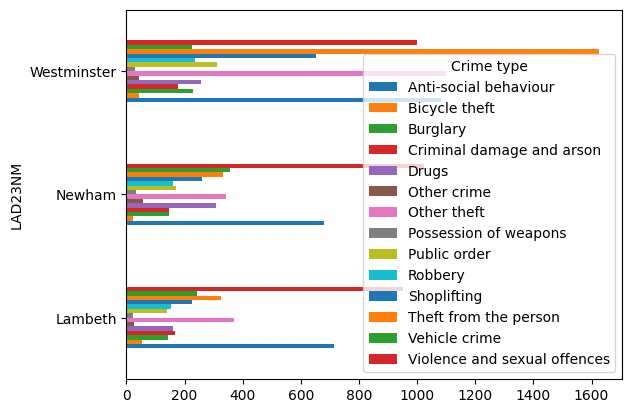

In [37]:
top_3_crimes.unstack().plot(kind='barh')

### Proportions of Suspects Charged
What proportion of the `Outcome type`s result in a `Outcome type` of `Suspect charged`

- Calculate the counts of the `Outcome type`s in the dataset that merged street with outcomes
  - You can either groupby `Crime type` and call the `size()` method or use `value_counts()`
- Divide that by the size of `Outcome type`s matching `Suspect charged` in the merged dataset
  - You can calculate this by filtering `Outcome type`s that match `Suspect charged` and grouping by `Crime type` and calling the `size()` method
- Sort and multiply by a `100` to get the percentage
- Create a Horizontal Bar Chart to display the data

<Axes: xlabel='Percent of Crimes Suspect Charged', ylabel='Crime type'>

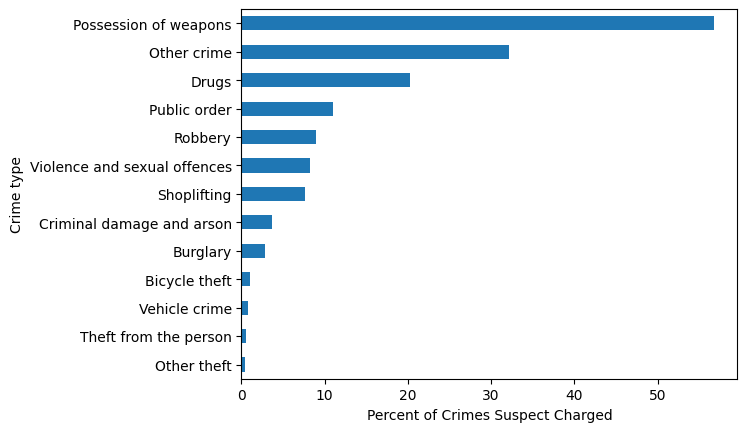

In [50]:
crime_counts = street_outcomes.groupby('Crime type').size()
charge_counts = street_outcomes[street_outcomes['Outcome type'] == 'Suspect charged'].groupby('Crime type').size()
charge_percentages = ((charge_counts/crime_counts)*100).sort_values(ascending=True)
charge_percentages.plot(kind='barh', xlabel="Percent of Crimes Suspect Charged")

### Charged Rate by LA
What percentage of the crimes with outcomes (the merged dataset) result in `Suspect charged` when grouped by Local Authority and Crime Type.

In [ ]:
crimes_count_by_auth_type = streets_with_authorities.groupby(['LAD23NM', 'Crime type']).size()
charged_count_by_auth_type = streets_with_authorities[streets_with_authorities['Outcome type'] == 'Suspect charged'].groupby(['LAD23NM', 'Crime type']).size()
charged_percent_by_auth_type = charged_count_by_auth_type / crimes_count_by_auth_type * 100


LAD23NM               Crime type                  
Barking and Dagenham  Bicycle theft                         NaN
                      Burglary                              NaN
                      Criminal damage and arson        1.351351
                      Drugs                           25.352113
                      Other crime                     37.500000
                      Other theft                           NaN
                      Possession of weapons           25.000000
                      Public order                    10.000000
                      Robbery                         22.916667
                      Shoplifting                      3.333333
                      Theft from the person                 NaN
                      Vehicle crime                         NaN
                      Violence and sexual offences     3.754266
Barnet                Bicycle theft                         NaN
                      Burglary                       

- Extract the data for the top three LAs

In [79]:
top_3_charged = charged_percent_by_auth_type[
    charged_percent_by_auth_type.index.get_level_values('LAD23NM').isin(top_3_la)
]
print(top_3_charged)

LAD23NM      Crime type                  
Lambeth      Bicycle theft                         NaN
             Burglary                              NaN
             Criminal damage and arson        3.603604
             Drugs                           42.105263
             Other crime                     57.142857
             Other theft                      0.796813
             Possession of weapons           71.428571
             Public order                     8.860759
             Robbery                          2.898551
             Shoplifting                      9.550562
             Theft from the person            1.886792
             Vehicle crime                         NaN
             Violence and sexual offences    10.682493
Newham       Bicycle theft                         NaN
             Burglary                         1.562500
             Criminal damage and arson        3.529412
             Drugs                           27.407407
             Other crim